In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("https://storage.googleapis.com/dqlab-dataset/RFM_customer.csv", encoding='utf8')

#Menghapus kolom customer_id
RFM_km = data.drop(["customer_id"], axis=1)

In [3]:
#Import StandardScaler
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
RFM_standardized = standard_scaler.fit_transform(RFM_km)
RFM_standardized = pd.DataFrame(RFM_standardized)
RFM_standardized.columns = ["Frequency","Monetary","Recency"]

In [11]:
#Penerapan RobustScaler
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
RFM_robust = robust_scaler.fit_transform(RFM_km)
RFM_robust = pd.DataFrame(RFM_robust)
RFM_robust.columns = ["Frequency","Recency","Monetary"]

In [12]:
#Import KMeans untuk mengimplementasikan K-Means Clustering
from sklearn.cluster import KMeans

#Import library matplotlib & seaborn
import matplotlib.pyplot as plt
import seaborn as sns

c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib

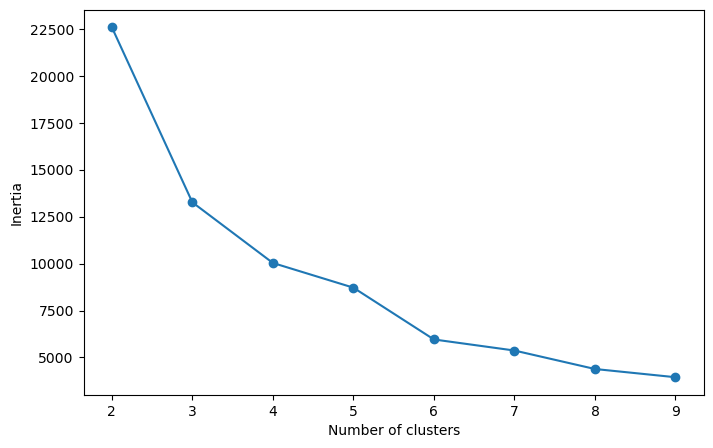

In [13]:
SSE = []
#Melakukan k-means berulang dengan nilai k yang berbeda-beda dari 2 sampai 10
for k in range(2, 10):
    k_means = KMeans(n_clusters=k, random_state=0)
    model = k_means.fit(RFM_robust)
    SSE.append(k_means.inertia_)
	
#Mengkonversi hasil ke dalam data frame, kemudian menampilkannya dalam bentuk plot
import matplotlib.pyplot as plt
frame = pd.DataFrame({"Cluster":range(2,10), "SSE":SSE})
plt.figure(figsize=(8,5))
plt.plot(frame["Cluster"], frame["SSE"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\ProgramData\anaconda3\envs\machine-learning-base\Lib

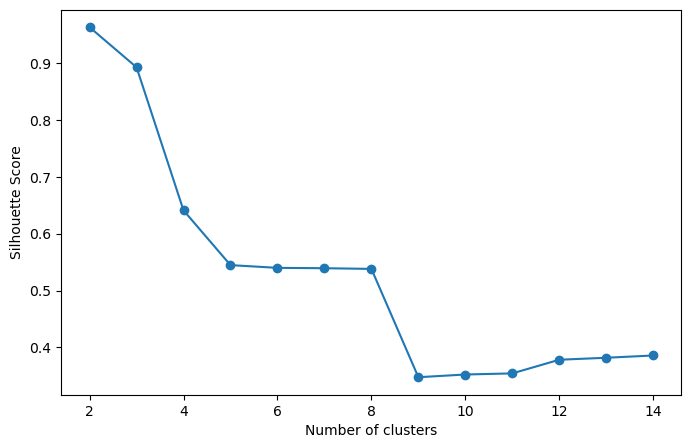

In [14]:
from sklearn.metrics import silhouette_score

#Melakukan k-means berkali-kali dengan nilai k yang berbeda-beda dari 2 sampai 15
silhouette = []
for k in range(2, 15):
    k_means = KMeans(n_clusters=k, random_state=0)
    model = k_means.fit(RFM_robust)
    silhouette.append(silhouette_score(RFM_robust, model.labels_))

#Mengkonversi hasil ke dalam data frame, kemudian menampilkannya dalam bentuk plot
frame = pd.DataFrame({"Cluster":range(2,15), "Silhouette Score":silhouette})
plt.figure(figsize=(8,5))
plt.plot(frame["Cluster"], frame["Silhouette Score"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [5]:
#Mengatur parameter k-means, jumlah cluster yang akan dibentuk adalah 3
k_means = KMeans(n_clusters=3, random_state=0)
k_means.fit(RFM_standardized)

#Pred menyimpan hasil prediksi label cluster untuk setiap data
pred = k_means.predict(RFM_standardized)

#Menggabungkan RFM dan hasil label clustering
RFM_labeled = pd.concat([RFM_standardized, pd.Series(pred).rename("cluster")], axis=1)

c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


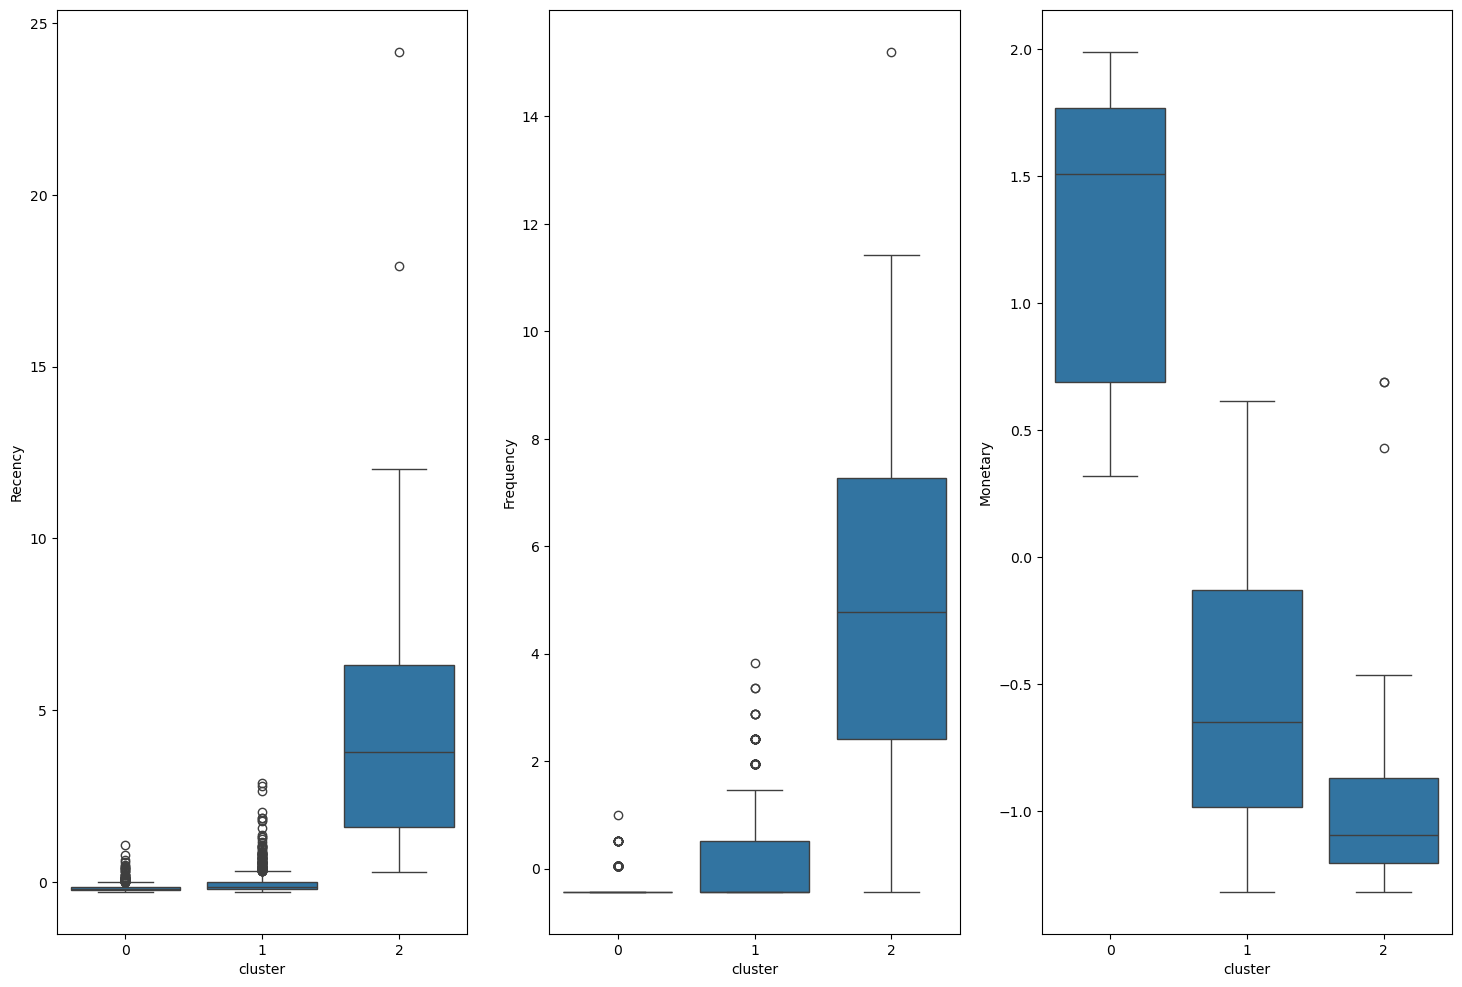

In [7]:
fig, ax = plt.subplots(1,3, figsize=(18,12))

#Menampilkan hasil clustering untuk setiap data dalam bentuk boxplot
sns.boxplot(x="cluster", y="Recency", data=RFM_labeled, ax=ax[0])
sns.boxplot(x="cluster", y="Frequency", data=RFM_labeled, ax=ax[1])
sns.boxplot(x="cluster", y="Monetary", data=RFM_labeled, ax=ax[2])
plt.show()

In [8]:
#Mengatur parameter k-Means
k_means4 = KMeans(n_clusters=4, random_state=0)
k_means5 = KMeans(n_clusters=5, random_state=0)

c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


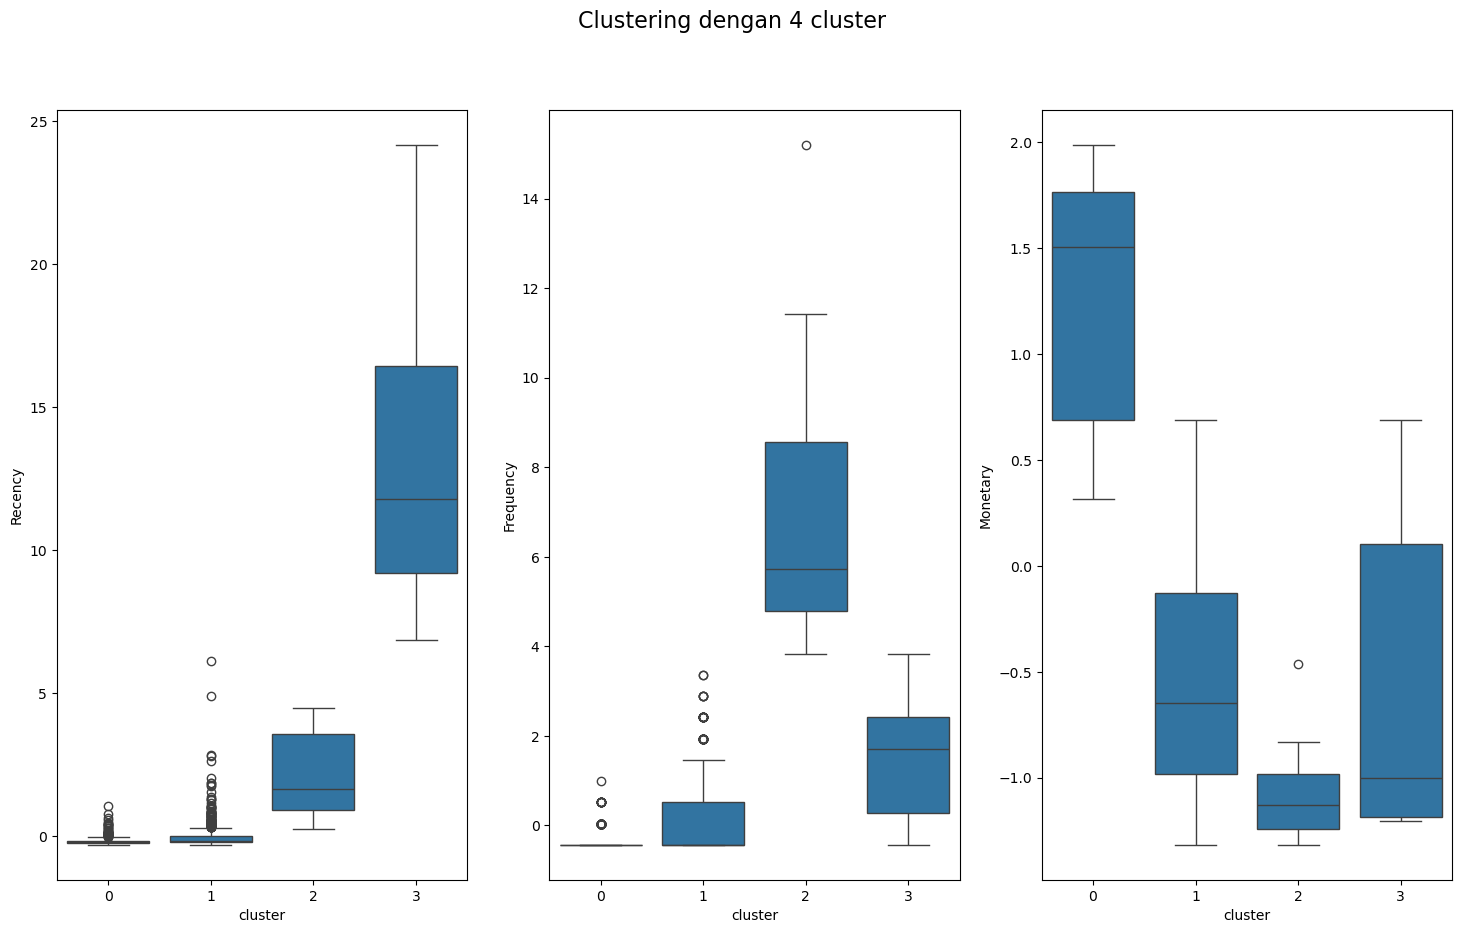

In [9]:
#Menjalankan algoritma k-means dengan jumlah cluster = 4
k_means4.fit(RFM_standardized)

#Pred menyimpan hasil prediksi label cluster untuk setiap data dengan jumlah cluster = 4
pred = k_means4.predict(RFM_standardized)

#Menggabungkan dataframe data dan hasil label clustering
RFM_labeled = pd.concat([RFM_standardized, pd.Series(pred).rename("cluster")], axis=1)

#Menampilkan hasil clustering untuk setiap data dalam bentuk boxplot
fig, ax = plt.subplots(1,3, figsize=(18,10))
sns.boxplot(x="cluster", y="Recency", data=RFM_labeled, ax=ax[0])
sns.boxplot(x="cluster", y="Frequency", data=RFM_labeled, ax=ax[1])
sns.boxplot(x="cluster", y="Monetary", data=RFM_labeled, ax=ax[2])
plt.suptitle("Clustering dengan 4 cluster", fontsize=16)
plt.show()

c:\ProgramData\anaconda3\envs\machine-learning-base\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


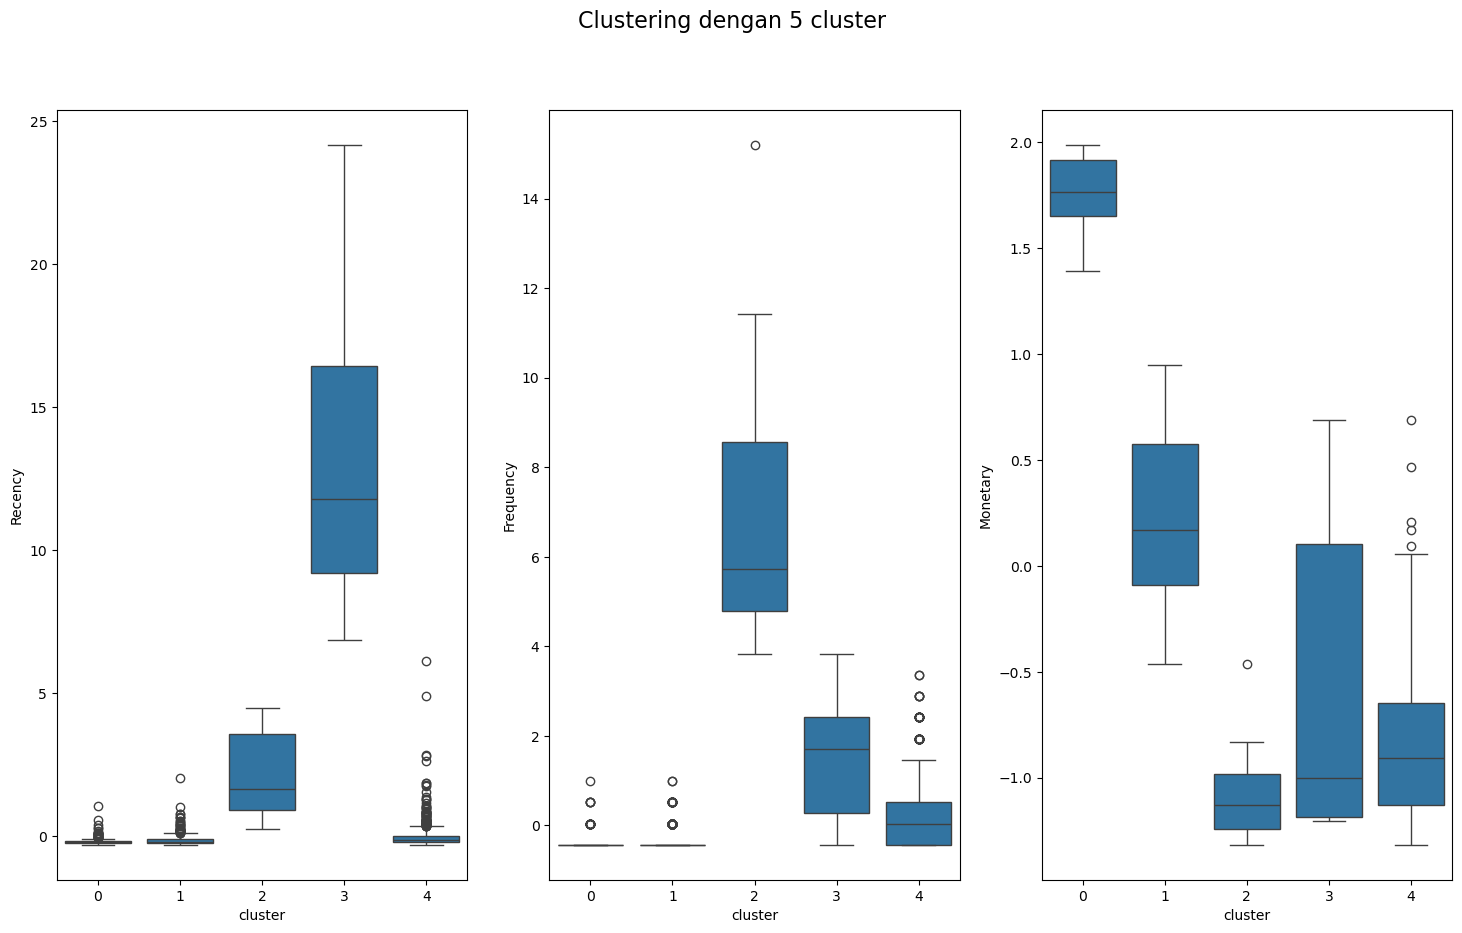

In [10]:
#Menjalankan algoritma k-means dengan jumlah cluster = 5
k_means5.fit(RFM_standardized)

#Pred menyimpan hasil prediksi label cluster untuk setiap data dengan jumlah cluster = 5
pred = k_means5.predict(RFM_standardized)

#Menggabungkan RFM dan hasil label clustering
RFM_labeled = pd.concat([RFM_standardized, pd.Series(pred).rename("cluster")], axis=1)

#Menampilkan hasil clustering untuk setiap data dalam bentuk boxplot
fig, ax = plt.subplots(1,3, figsize=(18,10))
sns.boxplot(x="cluster", y="Recency", data=RFM_labeled, ax=ax[0])
sns.boxplot(x="cluster", y="Frequency", data=RFM_labeled, ax=ax[1])
sns.boxplot(x="cluster", y="Monetary", data=RFM_labeled, ax=ax[2])
plt.suptitle("Clustering dengan 5 cluster", fontsize=16)
plt.show()